In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set(style="whitegrid")

df = pd.read_csv("E:\\covid19.csv")

df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

print("\nShape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Columns: ['Date', 'Country', 'NewCases', 'NewDeaths', 'TotalCases', 'TotalDeaths']

Shape: (750, 6)

First 5 Rows:
         Date  Country  NewCases  NewDeaths  TotalCases  TotalDeaths
0  2021-01-01    India       960         15         960           15
1  2021-01-01      USA      3872         21        3872           21
2  2021-01-01   Brazil       566         75         566           75
3  2021-01-01       UK      3544        100        3544          100
4  2021-01-01  Germany      3019        152        3019          152

Missing Values:
Date           0
Country        0
NewCases       0
NewDeaths      0
TotalCases     0
TotalDeaths    0
dtype: int64

Data Types:
Date           object
Country        object
NewCases        int64
NewDeaths       int64
TotalCases      int64
TotalDeaths     int64
dtype: object


In [6]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (if any)
df.fillna(0, inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop invalid dates
df = df.dropna(subset=['Date'])

In [7]:
#FEATURE ENGINEERING

# Extract Month & Year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [8]:
#DATA VALIDATION

print("\nSummary Statistics:")
print(df.describe())



Summary Statistics:
                      Date     NewCases   NewDeaths     TotalCases  \
count                  750   750.000000  750.000000     750.000000   
mean   2021-03-16 12:00:00  2612.632000  101.724000  196422.724000   
min    2021-01-01 00:00:00   102.000000    1.000000     566.000000   
25%    2021-02-07 00:00:00  1420.750000   52.000000  100600.500000   
50%    2021-03-16 12:00:00  2657.500000  104.000000  197157.000000   
75%    2021-04-23 00:00:00  3785.500000  152.000000  292205.000000   
max    2021-05-30 00:00:00  4995.000000  199.000000  402687.000000   
std                    NaN  1395.595772   57.692151  114245.729732   

        TotalDeaths       Month    Year  
count    750.000000  750.000000   750.0  
mean    7861.197333    3.000000  2021.0  
min       15.000000    1.000000  2021.0  
25%     4045.750000    2.000000  2021.0  
50%     8143.500000    3.000000  2021.0  
75%    11653.750000    4.000000  2021.0  
max    15942.000000    5.000000  2021.0  
std     4431

In [9]:
#DATA ANALYSIS

# Global trends
daily_cases = df.groupby('Date')['NewCases'].sum()
daily_deaths = df.groupby('Date')['NewDeaths'].sum()

# Monthly trend
monthly_cases = df.groupby('Month')['NewCases'].sum()

# Country-wise total cases
country_cases = df.groupby('Country')['TotalCases'].max().sort_values(ascending=False)

# Top 10 countries
top_countries = country_cases.head(10)

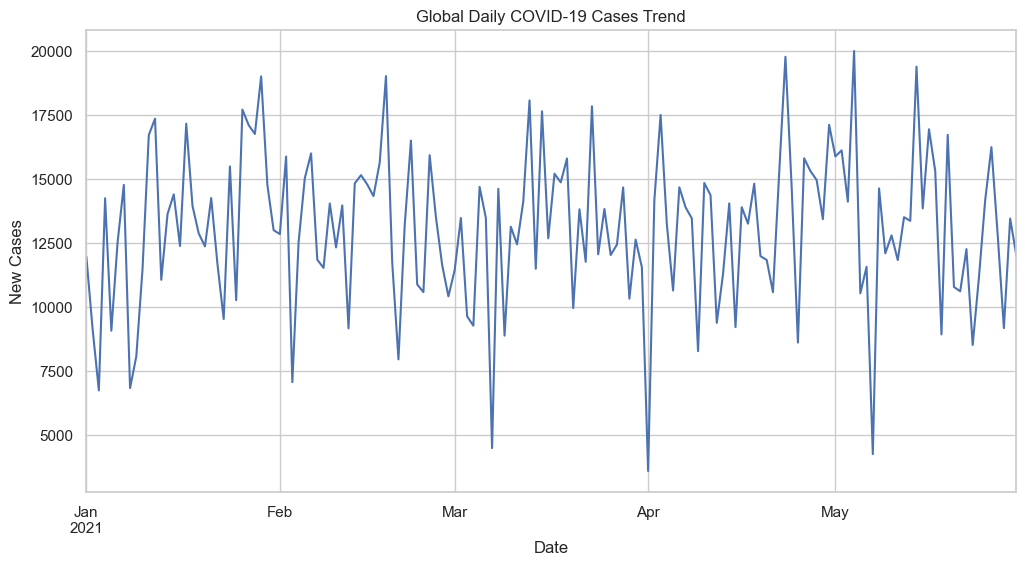

In [10]:
#Daily Cases Trend

plt.figure()
daily_cases.plot()
plt.title("Global Daily COVID-19 Cases Trend")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

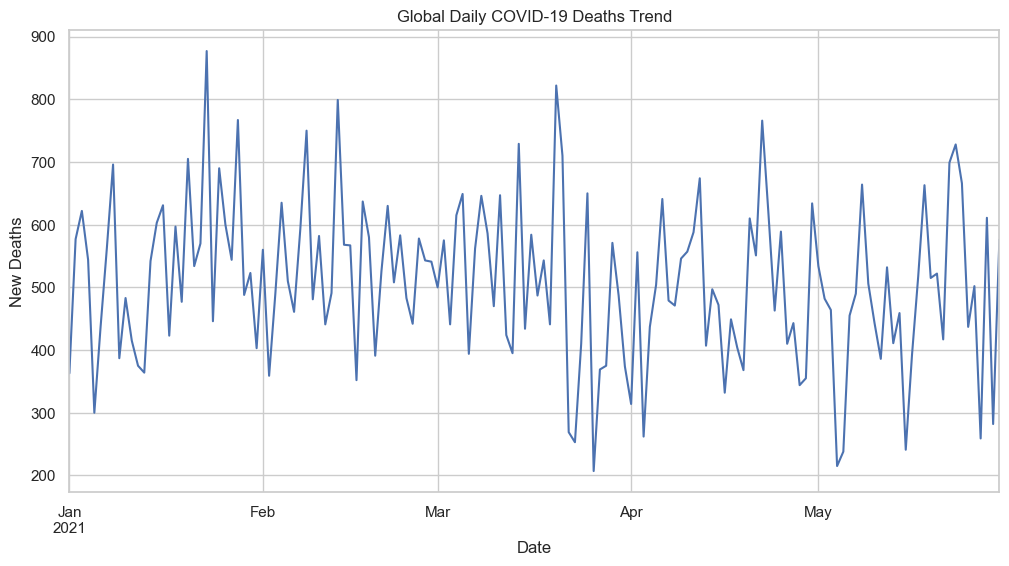

In [11]:
#Daily Deaths Trend

plt.figure()
daily_deaths.plot()
plt.title("Global Daily COVID-19 Deaths Trend")
plt.xlabel("Date")
plt.ylabel("New Deaths")
plt.show()

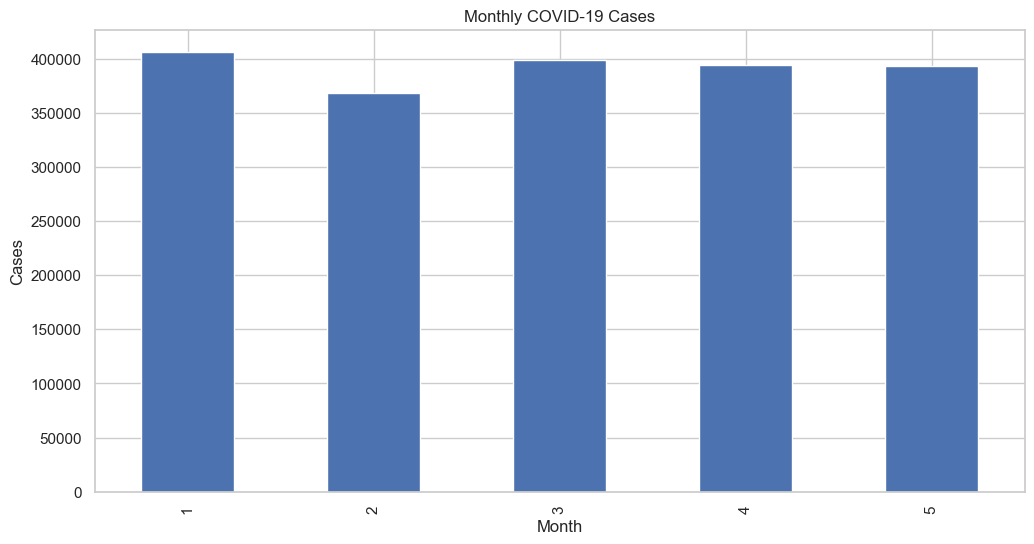

In [12]:
#Monthly Cases

plt.figure()
monthly_cases.plot(kind='bar')
plt.title("Monthly COVID-19 Cases")
plt.xlabel("Month")
plt.ylabel("Cases")
plt.show()

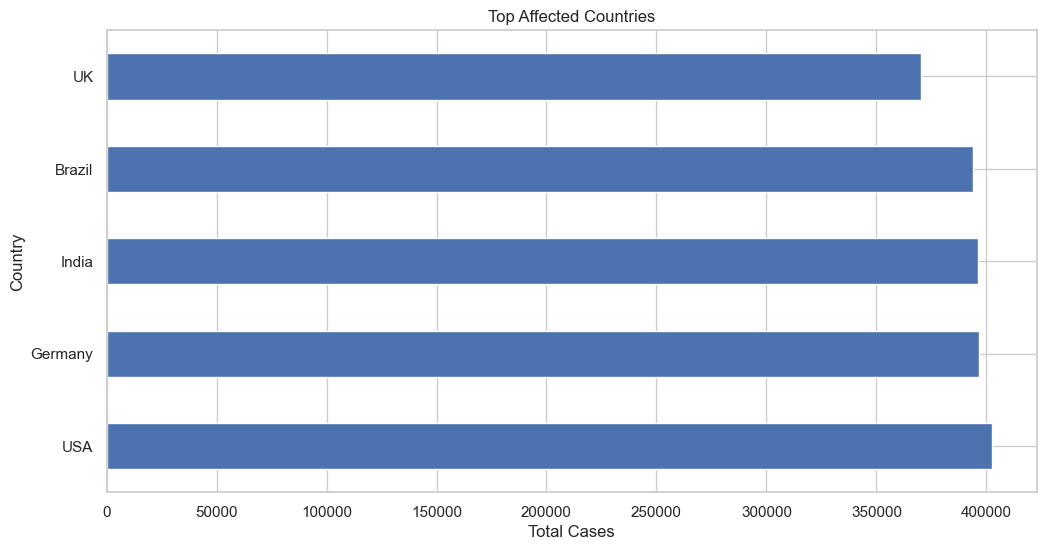

In [13]:
#Top Countries

plt.figure()
top_countries.plot(kind='barh')
plt.title("Top Affected Countries")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.show()

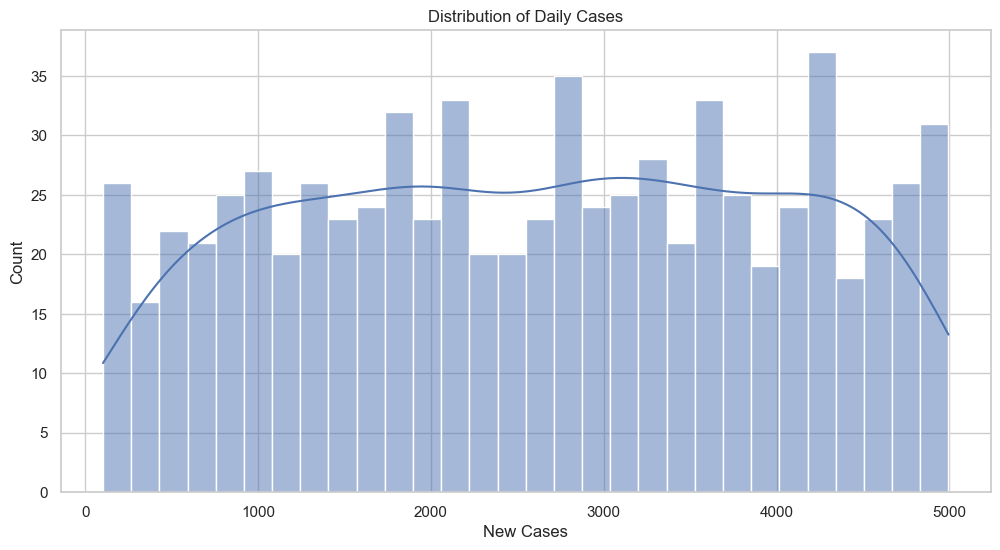

In [14]:
#Cases Distribution

plt.figure()
sns.histplot(df['NewCases'], bins=30, kde=True)
plt.title("Distribution of Daily Cases")
plt.xlabel("New Cases")
plt.show()

In [15]:
print("\n📊 Statistical Analysis:")

print("Mean Daily Cases:", df['NewCases'].mean())
print("Median Daily Cases:", df['NewCases'].median())
print("Std Deviation:", df['NewCases'].std())

print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))


📊 Statistical Analysis:
Mean Daily Cases: 2612.632
Median Daily Cases: 2657.5
Std Deviation: 1395.5957724174

Correlation Matrix:
             NewCases  NewDeaths  TotalCases  TotalDeaths     Month  Year
NewCases     1.000000  -0.100194    0.022323     0.011275 -0.000709   NaN
NewDeaths   -0.100194   1.000000   -0.072847    -0.062047 -0.078495   NaN
TotalCases   0.022323  -0.072847    1.000000     0.993031  0.976695   NaN
TotalDeaths  0.011275  -0.062047    0.993031     1.000000  0.976101   NaN
Month       -0.000709  -0.078495    0.976695     0.976101  1.000000   NaN
Year              NaN        NaN         NaN          NaN       NaN   NaN
